In [1]:
import zarr
import s3fs
import numpy as np
from scipy.linalg import solve_banded

S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/data.zarr", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)


In [2]:
z.shape

(1694, 5, 128, 129, 128)

In [3]:
data = z[510:1510:50]

In [4]:
data.shape

(20, 5, 128, 129, 128)

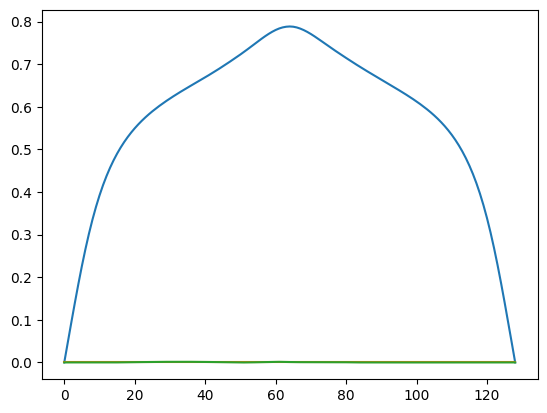

In [5]:
import matplotlib.pyplot as plt
    
plt.plot(data[:, 0].mean((0, 1, 3)))
plt.plot(data[:, 1].mean((0, 1, 3)))
plt.plot(data[:, 2].mean((0, 1, 3)))
plt.show()

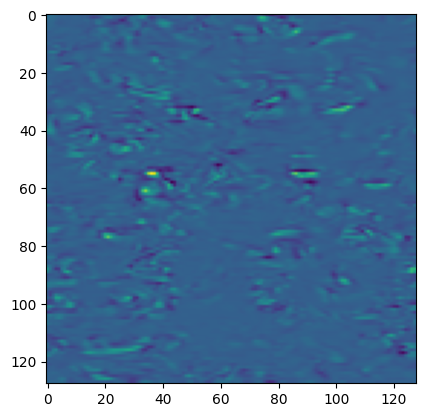

In [6]:
plt.imshow(data[6, 4, :, 50, :])
plt.show()

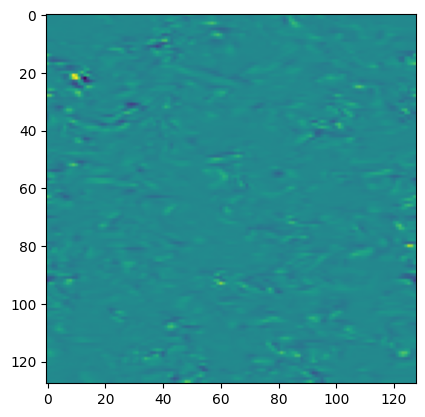

In [7]:
plt.imshow(data[7, 4, :, 50, :])
plt.show()

In [26]:
def broadcast_to(source, target, index):
    d = source.shape
    target_shape = list(target.shape)
    for i in range(len(target_shape)):
        if i != index:
            target_shape[i] = 1
    return source.reshape(tuple(target_shape))


def derive_fft(u, direction, h):
    n = u.shape[direction]
    k = 2.0 * np.pi * np.fft.fftfreq(n, d=h)
    k_broad = broadcast_to(k, u, direction)
    u_hat = np.fft.fftn(u, axes=(direction,))
    u_hat_prime = 1.0j * k_broad * u_hat
    return np.fft.ifftn(u_hat_prime, axes=(direction,)).real


def derive_compact(field, direction, dy):
    field_reordered = np.moveaxis(field, direction, 0)
    shape_reordered = field_reordered.shape
    rhs = np.zeros_like(field_reordered)
    rhs[1:-1] = field_reordered[2:] - field_reordered[0:-2]
    rhs[0, ...] = 0
    rhs[-1, ...] = 0
    rhs *= 3.0 / dy
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    ab[2, -2] = 0
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime

def derive_compact_6th(field, direction, dy):
    x = np.moveaxis(field, direction, 0)
    shape_reordered = x.shape
    rhs = np.zeros_like(x)
    rhs[1:-1] = x[:-2] - x[2:] 
    rhs *= 1.0 * dy / (3.0)
    length = field.shape[direction]
    ab = np.zeros((5, x.shape[0]))
    a = 1 / 18
    b = 4 / 9
    c = -1
    ab[0, 3:] = a
    ab[1, 2:] = b
    ab[2, :] = c
    ab[3, :-2] = b
    ab[4, :-3] = a
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((2, 2), ab, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime
    
def get_grad_func(channel):
    yp = channel['y']
    Lx = 12.57
    Nx = 128
    Ly = 2.0
    Ny = 129
    Lz = 4.19
    Nz = 128
    delta_yp = np.gradient(yp, Ly / (Ny - 1))
    y_stretching = 1.0 / delta_yp
    
    def grad(field):
        T, C, X, Y, Z = field.shape
        grad = np.zeros((T, C, 3, X, Y, Z))
        grad[:, :, 0, :, :, :] = derive_fft(field, 2, Lx / Nx)
        grad[:, :, 1, :, :, :] = derive_compact(field, 3, Ly / (Ny - 1)) * y_stretching[None, None, None, :, None]  # 0.0386
        # grad[:, :, 1, :, :, :] = np.gradient(field, yp, axis=3)  # 0.0424
        # grad[:, :, 1, :, :, :] = derive_compact_6th(field, 3, Ly / (Ny - 1)) * y_stretching[None, None, None, :, None] # broken
        grad[:, :, 2, :, :, :] = derive_fft(field, 4, Lz / Nz)
        return grad

    return grad

In [27]:
store = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/channel.zarr", s3=fs)
channel_z = zarr.open(
    store=store,
    mode="r",
)
channel = {'x': channel_z['x'][:], 'y': channel_z['y'][:], 'z': channel_z['z'][:]}
y = channel["y"]

In [28]:
grad = get_grad_func(channel)

In [29]:
u_grad = grad(data[:, :3])

In [30]:
u_grad.shape

(20, 3, 3, 128, 129, 128)

In [31]:
Q = -0.5 * np.einsum('tij..., tji...->t...', u_grad, u_grad)

In [32]:
def L1(X, Y):
    return np.mean(np.abs(X - Y))
def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))
def rel_rmse(X, Y):
    return rmse(X, Y) / np.sqrt(np.mean(Y**2))

In [33]:
rel_rmse(Q, data[:, 4])

np.float64(0.04245416164381559)

In [ ]:
rel_rmse(Q, data[:, 4])

In [ ]:
channel["x"][-1]

In [ ]:
channel["z"][-1]

In [ ]:
np.sqrt(np.mean(data[:, 4, :, 0, :] ** 2))

In [ ]:
np.sqrt(np.mean(data[:, 4, :, -1, :] ** 2))

In [ ]:
np.sqrt(np.mean(Q[:, :, 0, :] ** 2))

In [ ]:
np.sqrt(np.mean(Q[:, :, -1, :] ** 2))

In [ ]:
plt.title("Q norm comparison between computed from velocity and data along y index")
plt.plot(y, np.sqrt(np.mean((data[:, 4]) ** 2, axis=(0, 1, 3))), label="data")
plt.plot(y, np.sqrt(np.mean((Q) ** 2, axis=(0, 1, 3))), label="computed")
plt.legend()
plt.xlabel("y index")
plt.ylabel("norm")
plt.show()

In [ ]:
plt.title("RMSE between Q from data and computed from velocity along y index")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))))
plt.xlabel("y index")
plt.ylabel("RMSE")
plt.show()

In [ ]:
plt.title("Relative RMSE between Q from data and computed from velocity along y index")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))) / np.sqrt(np.mean((data[:, 4]) ** 2, axis=(0, 1, 3))))
plt.xlabel("y index")
plt.ylabel("relative error")
plt.show()

In [ ]:
plt.title("Relative RMSE between Q from data and computed from velocity along y index [EXCLUDING BOUNDARIES]")
plt.plot(np.sqrt(np.mean((Q[:, :, 2:-2] - data[:, 4, :, 2:-2]) ** 2, axis=(0, 1, 3))) / np.sqrt(np.mean((data[:, 4, :, 2:-2]) ** 2, axis=(0, 1, 3))))
plt.xlabel("y index")
plt.ylabel("relative error")
plt.show()

In [ ]:
rel_rmse(Q, data[:, 4])

In [ ]:
u_div = u_grad[:, 0, 0] + u_grad[:, 1, 1] + u_grad[:, 2, 2]

In [ ]:
u_div.mean()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Divergence through time and y")
ax[0].plot(u_div.mean(axis=(1, 2, 3)))
ax[1].plot(u_div.mean(axis=(0, 1, 3)))
plt.show()

In [ ]:
bc = (data[:, :3, :, 0, :] + data[:, :3, :, -1, :] ).sum()

In [ ]:
bc

In [ ]:
xz_mean = data[:, :3].mean((2, 4))
stationarity = xz_mean[1:] - xz_mean[:-1]

In [ ]:
plt.title("Stationarity over time")
plt.plot(stationarity.mean((1, 2)))
plt.xlabel("time")
plt.ylabel("d⟨u⟩/dt")
plt.show()

In [ ]:
nu = 1/4763
dy_wall = channel["y"][1] - channel["y"][0]
u_tau = np.array([np.sqrt(nu * data[:, 0].mean((0, 1, 3))[1] / dy_wall),  np.sqrt(nu * data[:, 0].mean((0, 1, 3))[-2] / (channel["y"][-1] - channel["y"][-2]))])

In [ ]:
re_t = u_tau.mean() / nu

In [ ]:
re_t

In [ ]:
u_tau

In [ ]:
data[:, 0].mean((0, 1, 3))[0]

In [ ]:
data[:, -1].mean((0, 1, 3))[0]

In [ ]:
data.shape

In [ ]:
u_mean = data[:, 0].mean((1, 3))
Ly = 2.0
Ny = 129
delta_yp = np.gradient(y, Ly / (Ny - 1))
y_stretching = 1.0 / delta_yp 
du_dy = derive_compact(u_mean, 1, Ly / (Ny - 1)) * y_stretching
du_dy = np.gradient(u_mean, y, axis=1)

In [ ]:
wall_grads = np.array([du_dy[:, 0], -du_dy[:, -1]])

In [ ]:
wall_grads.mean(1)

In [ ]:
nu = 1/4763
u_tau = np.sqrt(nu * wall_grads.mean((0)))
re_t = u_tau / nu

In [ ]:
u_tau

In [ ]:
plt.title("Friction Re through time")
plt.plot(re_t)
plt.show()

In [ ]:
re_t.mean()

In [ ]:
u_tau.mean()

In [ ]:
u_mean = data[:, 0].mean((0, 1, 3))
Ly = 2.0
Ny = 129
delta_yp = np.gradient(y, Ly / (Ny - 1))
y_stretching = 1.0 / delta_yp 
du_dy_avg = derive_compact(u_mean, 0, Ly / (Ny - 1)) * y_stretching
du_dy_avg = np.gradient(u_mean, channel["y"])
wall_grads_avg = np.array([du_dy_avg[0], -du_dy_avg[-1]])
nu = 1/4763
u_tau_avg = np.sqrt(nu * wall_grads_avg.mean((0)))
re_t_avg = u_tau_avg / nu

In [ ]:
u_tau_avg

In [ ]:
re_t_avg

In [ ]:
nu = 1/4763
u = data[:, 0]
v = data[:, 1]
u_mean = u.mean((0, 1, 3))
v_mean = v.mean((0, 1, 3))

du_dy = np.gradient(u_mean, channel["y"])
viscous_stress = nu * du_dy

u_prime = u - u_mean[None, None, :, None]
v_prime = v - v_mean[None, None, :, None]
re_stress = -np.mean(u_prime * v_prime, (0, 1, 3))
tau_total = viscous_stress + re_stress

In [ ]:
tau_wall = nu * u_mean[1] / dy_wall
slope = -tau_wall
y_lim = 65
plt.title("Stresses profiles along y")
plt.xlabel("y")
plt.ylabel("Normalized value (by wall stress)")
# plt.plot(y[:y_lim], slope * y[:y_lim] / tau_wall + 1, label="Ideal total stress")
plt.plot(y[:y_lim], tau_total[:y_lim] / tau_wall, label="Total stress")
plt.plot(y[:y_lim], viscous_stress[:y_lim] / tau_wall, label="Viscous stress")
plt.plot(y[:y_lim], re_stress[:y_lim] / tau_wall, label="Reynolds stress")
plt.legend()
plt.show()

In [ ]:
u_mean.shape

In [ ]:
nu = 1 / 4763
u_mean = data[:, 0].mean((0, 1, 3))
# (u stuff) / 2 delta
u_bulk = np.trapezoid(u_mean, y) / y[-1]

In [ ]:
re_b = u_bulk / nu

In [ ]:
re_b

In [ ]:
plt.plot(y, u_mean)
plt.show()

In [ ]:
u_bulk

In [ ]:
y[1]

In [ ]:
u_mean.shape

In [ ]:
U_centerline = u_mean[64]

In [ ]:
U_centerline

In [ ]:
u_tau.mean()

In [ ]:
U_centerline / u_tau.mean()

In [ ]:
re = 200.0
yly = 2.0
re_cent = (re/0.116)**(1.0/0.88)
fcpg = 2/yly * (re/re_cent)**2
delta = 1.0
u_tau_forcing = (delta*fcpg)**0.5

In [ ]:
u_tau_forcing

In [ ]:
u_tau_stress = np.sqrt(np.abs(tau_wall))

In [ ]:
u_tau_stress